## **Evaluación y Análisis Comparativo en Test**

En primer lugar, enfrentamos los baselines intra-dominio y el modelo global a la partición de test del corpus unificado. Recordamos la configuración óptima de cada uno de ellos tras el ajuste de hiperparámetros:

* **Corpus Global Unificado (MELD + IEMOCAP)**: 
    * Arquitectura de Fusión mediante Atención:
        - **Ventana de Vídeo**: 32 frames
        - **Ventana de Audio**: 7 segundos
        - **Ventana de Texto**: 32 tokens
        - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
        - **Learning Rate**: 5e-05
        - **Dropout**: 0.3

* **Dataset MELD**:
    * Arquitectura de Fusión Tardía mediante Regresión Logística:
        - **Ventana de Vídeo**: 32 frames
        - **Ventana de Audio**: 7 segundos
        - **Ventana de Texto**: 32 tokens
        - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
        - **Learning Rate**: 0.0001
        - **Dropout**: 0.5

* **Dataset IEMOCAP**:
    * Arquitectura de Fusión Temprana:
        - **Ventana de Vídeo**: 32 frames
        - **Ventana de Audio**: 7 segundos
        - **Ventana de Texto**: 32 tokens
        - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
        - **Learning Rate**: 0.0001
        - **Dropout**: 0.3


A continuación, se realiza un análisis comparativo en test con respecto a los baselines unimodales/bimodales ajustados, y un análisis de sesgo de **género**/**dominio** de nuestro modelo global (entrenado sobre el corpus global unificado), con el objetivo de determinar la robustez del mismo frente a esto. 

Adicionalmente, para observar el espacio latente aprendido de todos los modelos (baselines y modelo global), al final del notebook aplicamos **t-SNE**. 


In [1]:
# Importamos las librerías necesarias:

import os
import pandas as pd
import re
import subprocess
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from data.dataset import MultimodalStressDataset
from models.fusion_strategies import EarlyFusion, LateFusion, AttentionFusion
from models.unimodal_classifier import UnimodalClassifier
from models.adapters import VisualAdapter, AudioAdapter, TextAdapter
from torch.utils.data import DataLoader
import torch.nn as nn
from IPython.display import display, Image
import matplotlib.patches as mpatches

BASE_DIR = os.path.expanduser('/workspace')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

----
----
# **Evaluación en TEST de modelo global y baselines intra-dominio**
---
## **Arquitectura entrenada con Dataset Global Unificado (MELD + IEMOCAP)**

In [4]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:20<00:00, 204.62it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.59 ms / muestra
ROC-AUC Score: 0.7837
F1 Macro: 0.6891
F1 Weighted: 0.7690
Accuracy (en %): 75.69%
Balanced Accuracy (en %): 71.73%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 ', returncode=0)

---
## **Arquitectura entrenada con Dataset MELD**

In [5]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:12<00:00, 204.60it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.69 ms / muestra
ROC-AUC Score: 0.7902
F1 Macro: 0.6664
F1 Weighted: 0.8120
Accuracy (en %): 79.72%
Balanced Accuracy (en %): 70.16%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 ', returncode=0)

---
## **Arquitectura entrenada con Dataset IEMOCAP**

In [6]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 209.06it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.57 ms / muestra
ROC-AUC Score: 0.7877
F1 Macro: 0.6860
F1 Weighted: 0.7046
Accuracy (en %): 69.68%
Balanced Accuracy (en %): 71.02%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 ', returncode=0)

---
#### **Tabla Final**

In [7]:
#  Definimos las rutas exactas de los 3 modelos campeones evaluados en TEST
rutas_resultados = [
    {
        "Dataset": "Global Unificado",
        "nombre": "Fusión mediante Atención",
        "reporte": "resultados/inter_test/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_global_test.txt",
        "modelo": "pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"
    },
    {
        "Dataset": "MELD",
        "nombre": "Fusión Tardía (Regresión Logística)",
        "reporte": "resultados/intra_test/MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_MELD_test.txt",
        "modelo": "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"
    },
    {
        "Dataset": "IEMOCAP",
        "nombre": "Fusión Temprana",
        "reporte": "resultados/intra_test/IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_IEMOCAP_test.txt",
        "modelo": "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"
    }
]

########### ---------- FUNCIÓN DE EXTRACCIÓN DE HIPERPARÁMETROS DEL NOMBRE DEL MODELO (.pth) ------------##############

def extraer_hiperparametros(nombre_archivo):
    """Extrae tamaño de las ventanas y arquitectura desde el nombre del archivo (.pth)"""
    try:
        v_win = re.search(r'resnet(\d+)', nombre_archivo).group(1) 
        a_win = re.search(r'wav2vec(\d+)s', nombre_archivo).group(1) 
        t_win = re.search(r'roberta(\d+)', nombre_archivo).group(1) 
        proj = re.search(r'_p(\d+)', nombre_archivo).group(1) 
        hidden = re.search(r'_h(\d+)', nombre_archivo).group(1) 
        lr = re.search(r'_lr([\d.e-]+)', nombre_archivo).group(1) 
        dropout = re.search(r'_do([\d.]+)', nombre_archivo).group(1).rstrip('.') 
        return v_win, a_win, t_win, proj, hidden, lr, dropout
    except AttributeError:
        return "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"
    
########### ---------- FUNCIÓN DE EXTRACCIÓN DE MÉTRICAS A PARTIR DEL REPORTE .txt ------------##############

def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

datos_extraidos = []

for item in rutas_resultados:
    ruta_txt = item["reporte"]
    
    if os.path.exists(ruta_txt):
        f1, ba, auc, recall = extraer_metricas_txt(ruta_txt)
        v_win, a_win, t_win, proj, hidden, lr, dropout = extraer_hiperparametros(item["modelo"])
        
        datos_extraidos.append({
            "Dataset": item["Dataset"],
            "Técnica de Fusión": item["nombre"],
            "V_frames": v_win,
            "A_seg": a_win,
            "T_tokens": t_win,
            "Proj_Dim": proj,
            "Hidden_MLP": hidden,
            "LR": lr,
            "Dropout": dropout,
            "F1-Score Macro": f1,
            "Balanced Accuracy": ba,
            "ROC-AUC": auc,
            "Recall (Estrés)": recall
        })
    else:
        print(f"No se encontró el archivo reporte para {item['Dataset']} en: {ruta_txt}")

# CREACIÓN Y EXPORTACIÓN DEL DATAFRAME
df_resultados = pd.DataFrame(datos_extraidos)

if not df_resultados.empty:
    # Ordenamos por F1-Score Macro
    df_resultados = df_resultados.sort_values(by="F1-Score Macro", ascending=False).reset_index(drop=True)
    
    # Exportamos a CSV 
    df_resultados.to_csv("resultados_finales_modelos_seleccionados_test.csv", index=False)
    
    # Formato visual para mostrar en el notebook:
    columnas_colores = ['F1-Score Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
    styled_df = df_resultados.style.background_gradient(subset=columnas_colores, cmap='Purples')\
                                   .format({
                                       'F1-Score Macro': '{:.4f}',
                                       'Balanced Accuracy': '{:.4f}',
                                       'ROC-AUC': '{:.4f}',
                                       'Recall (Estrés)': '{:.4f}'
                                   })\
                                   .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Dataset'])\
                                   .set_caption("Evaluación Final en Partición de TEST - Modelos Seleccionados")
    
    display(styled_df)
else:
    print("\nNo se ha generado la tabla.")

,Dataset,Técnica de Fusión,V_frames,A_seg,T_tokens,Proj_Dim,Hidden_MLP,LR,Dropout,F1-Score Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Global Unificado,Fusión mediante Atención,32,7,32,512,128,5e-05,0.3,0.6891,0.7173,0.7837,0.6454
1,IEMOCAP,Fusión Temprana,32,7,32,512,128,0.0001,0.3,0.6860,0.7102,0.7877,0.7522
2,MELD,Fusión Tardía (Regresión Logística),32,7,32,512,128,0.0001,0.5,0.6664,0.7016,0.7902,0.5646


---------------------------
-----------------------------
## **Análisis Comparativo en TEST: Baselines Unimodales, Bimodales, Intra-dominio y Global**

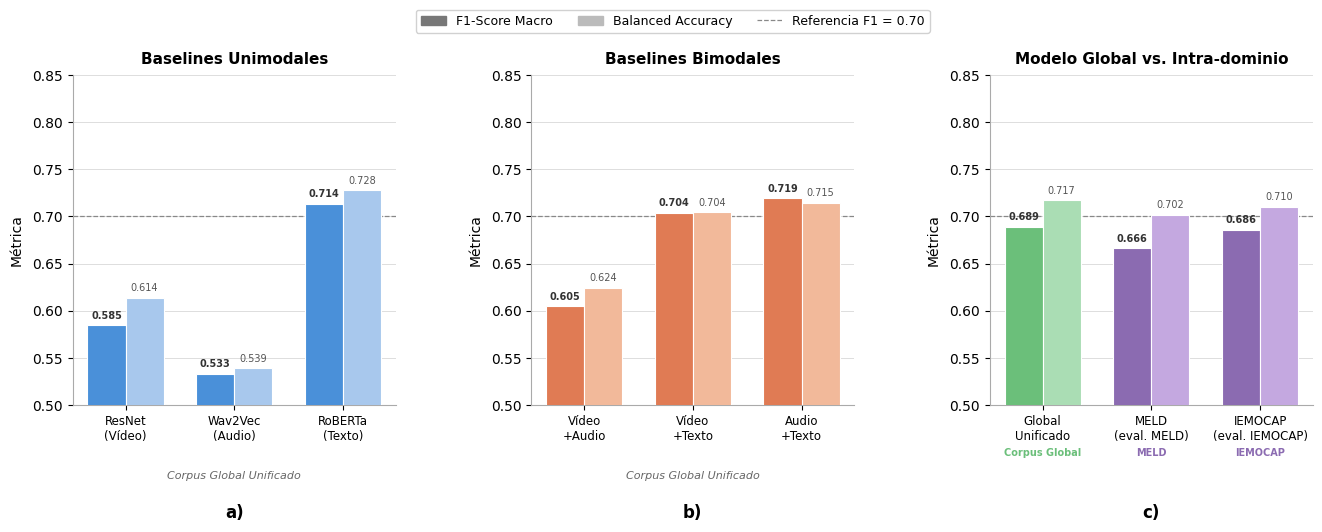

In [14]:
rutas_resultados = [
    # GLOBAL
    {"grupo": "global", "etiqueta": "Global\nUnificado",
     "reporte": "resultados/inter_test/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_global_test.txt"},
    # INTRA-DOMINIO
    {"grupo": "intra", "etiqueta": "MELD\n(eval. MELD)",
     "reporte": "resultados/intra_test/MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_MELD_test.txt"},
    {"grupo": "intra", "etiqueta": "IEMOCAP\n(eval. IEMOCAP)",
     "reporte": "resultados/intra_test/IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_IEMOCAP_test.txt"},
    # BIMODALES
    {"grupo": "bimodal", "etiqueta": "Vídeo\n+Audio",
     "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_global_test.txt"},
    {"grupo": "bimodal", "etiqueta": "Vídeo\n+Texto",
     "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_global_test.txt"},
    {"grupo": "bimodal", "etiqueta": "Audio\n+Texto",
     "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_global_test.txt"},
    # UNIMODALES
    {"grupo": "unimodal", "etiqueta": "ResNet\n(Vídeo)",
     "reporte": "resultados/unimodales/test/reporte_final_baseline_unimodal_VIDEO_resnet_test.txt"},
    {"grupo": "unimodal", "etiqueta": "Wav2Vec\n(Audio)",
     "reporte": "resultados/unimodales/test/reporte_final_baseline_unimodal_AUDIO_wav2vec_test.txt"},
    {"grupo": "unimodal", "etiqueta": "RoBERTa\n(Texto)",
     "reporte": "resultados/unimodales/test/reporte_final_baseline_unimodal_TEXTO_roberta64_test.txt"},
]

# Extraemos las métricas de cada uno de los modelos: 
datos = {}
for item in rutas_resultados:
    f1, ba, auc, recall = extraer_metricas_txt(item["reporte"])
    datos[item["etiqueta"]] = {"f1": f1, "ba": ba, "grupo": item["grupo"]}

subfiguras = [ # Organizamos las información a mostrar en cada subfigura a continuación:
    {
        "titulo": "Baselines Unimodales",
        "subtitulo": "Corpus Global Unificado",
        "etiquetas": ["ResNet\n(Vídeo)", "Wav2Vec\n(Audio)", "RoBERTa\n(Texto)"],
        "color_f1": "#4A90D9",
        "color_ba": "#A8C8ED",
    },
    {
        "titulo": "Baselines Bimodales",
        "subtitulo": "Corpus Global Unificado",
        "etiquetas": ["Vídeo\n+Audio", "Vídeo\n+Texto", "Audio\n+Texto"],
        "color_f1": "#E07B54",
        "color_ba": "#F2B99A",
    },
    {
        "titulo": "Modelo Global vs. Intra-dominio",
        "subtitulo": None,
        "etiquetas": ["Global\nUnificado", "MELD\n(eval. MELD)", "IEMOCAP\n(eval. IEMOCAP)"],
        "color_f1": ["#6BBF7A", "#8B6BB1", "#8B6BB1"],
        "color_ba": ["#AADDB4", "#C4A8E0", "#C4A8E0"],
    },
]

subtitles = ["a)", "b)", "c)"]

# ---------------------------- FIGURA -----------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)
fig.subplots_adjust(wspace=0.42, bottom=0.28)

bar_width = 0.35

for ax, sf, subtitle in zip(axes, subfiguras, subtitles):
    etiquetas = sf["etiquetas"]
    n = len(etiquetas)
    x = np.arange(n)

    f1_vals = [datos.get(e, {}).get("f1", 0.0) for e in etiquetas]
    ba_vals = [datos.get(e, {}).get("ba", 0.0) for e in etiquetas]

    c_f1 = sf["color_f1"] if isinstance(sf["color_f1"], list) else [sf["color_f1"]] * n
    c_ba = sf["color_ba"] if isinstance(sf["color_ba"], list) else [sf["color_ba"]] * n

    # Barras de las métricas de F1 y BA al lado (la de balanced_accuracy se muestra con el mismo tono de color pero con menor intensidad):
    bars_f1 = ax.bar(x - bar_width/2, f1_vals, width=bar_width,
                     color=c_f1, edgecolor="white", linewidth=0.8,
                     zorder=3, label="F1-Score Macro")
    bars_ba = ax.bar(x + bar_width/2, ba_vals, width=bar_width,
                     color=c_ba, edgecolor="white", linewidth=0.8,
                     zorder=3, label="Balanced Accuracy")

    # Mostramos los valores encima de cada barra:
    ################ F1-SCORE MACRO ################
    for bar, val in zip(bars_f1, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7, color="#333333", fontweight="bold")
    ################ BALANCED ACCURACY ################
    for bar, val in zip(bars_ba, ba_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7, color="#555555") #lo mostramos un poco más claro

    # Línea de referencia en 0.7
    ax.axhline(0.70, color="#888888", linewidth=0.9, linestyle="--", zorder=2)

    ax.set_ylim(0.50, 0.85)
    ax.set_yticks(np.arange(0.50, 0.86, 0.05))
    ax.set_ylabel("Métrica", fontsize=10, labelpad=6)
    ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=8.5)
    ax.set_title(sf["titulo"], fontsize=11, fontweight="bold", pad=8)

    # Añadimos un subtítulo de corpus debajo del eje X:
    if sf["subtitulo"]:
        ax.text(0.5, -0.20, sf["subtitulo"], transform=ax.transAxes,
                ha="center", va="top", fontsize=8,
                color="#666666", style="italic")
    if sf["titulo"] == "Modelo Global vs. Intra-dominio":
        ax.text(x[0], -0.13, "Corpus Global", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7, color="#6BBF7A", fontweight="bold")
        ax.text(x[1], -0.13, "MELD", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7, color="#8B6BB1", fontweight="bold")
        ax.text(x[2], -0.13, "IEMOCAP", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7, color="#8B6BB1", fontweight="bold")

    ax.text(0.5, -0.30, subtitle, transform=ax.transAxes,
            ha="center", va="top", fontsize=12, fontweight="bold")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")

# Añadimos una leyenda global:
patch_f1  = mpatches.Patch(color="#777777", label="F1-Score Macro")
patch_ba  = mpatches.Patch(color="#BBBBBB", label="Balanced Accuracy")
ref_line  = plt.Line2D([0], [0], color="#888888", linewidth=0.9,
                        linestyle="--", label="Referencia F1 = 0.70")
fig.legend(handles=[patch_f1, patch_ba, ref_line],
           loc="upper center", ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, 1.01),
           framealpha=0.9, edgecolor="#CCCCCC")

plt.savefig("Fig_Comparativa_Global_Baselines_Test.pdf",
            dpi=300, bbox_inches="tight", format="pdf")
plt.show()

### **Análisis Comparativo Modelos Intra-dominio vs Modelo Global**

En base a los resultados obtenidos en las cuatro métricas principales observadas en la tabla:

Destaca que los tres modelos presentan valores muy similares en ROC-AUC presentando por tanto una capacidad similar a la hora de separar la clase de "estrés" y "no estrés". Cada uno, empleando su técnica de fusión correspondiente, logra ser lo suficientemente robusto para la tarea. 

* **Modelo de Dataset Global Unificado**: Logra alcanzar la primera posición en F1-Score Macro y Balanced Accuracy, indicando que permite identificar mejor que el resto las muestras de estrés y no estrés, mostrando un recall y ROC-AUC por debajo de 0.8. 

* **Modelo de Dataset MELD**: Es el que se posiciona como el peor modelo en F1-Score Macro y Balanced Accuracy, siendo el que peor logra diferenciar correctamente las muestras de estrés y no estrés entre ellas. 

* **Modelo de Dataset IEMOCAP**: En este caso, sorprende que presenta un F1-Score Macro y Balanced Accuracy similar al primer modelo, presentando además un Recall alto. 

### **Análisis Comparativo Baselines Unimodales vs Modelo Global**

Vemos que el baseline de RoBERTa domina en las 4 métricas (si comparamos las tablas obtenidas en test), siendo el **recall** la métrica que más cae con respecto a las demás para todos los modelos unimodales. En la gráfica, se observa que el modelo entrenado sobre el corpus unificado obtiene un rendimiento ligeramente inferior al unimodal de RoBERTa, indicando que la fusión ha aportado al modelo cierto ruido en lugar de complementarse adecuadamente todas las modalidades. A pesar de esto, la caída en el rendimiento es mínima, consiguiendo mantener buenos resultados en test para ambas métricas.

### **Análisis Comparativo Baselines Bimodales vs Modelo Global**

Podemos observar que los resultados en ambas métricas (F1-Score Macro y Balanced Accuracy) están muy igualados, siendo el que peor rendimiento alcanza el baseline de vídeo y audio. Esto puede indicar que, para este corpus unificado de MELD e IEMOCAP, el modelo, en lugar de verse beneficiado realmente por la sinergia multimodal del audio, vídeo y texto, lo que hace esto es aportar cierto ruido a la hora de tomar la decisión, alineado con las conclusiones obtenidas al comparar con los baselines unimodales. Se verá a continuación en la evaluación de transferencia de aprendizaje si esta tendencia se mantiene ante el tercer dataset MSP-IMPROV. 

----------------
---------------

## **Análisis de sesgo de dominio del modelo Global**

Para comprobar que el modelo no está sesgado a una fuente de datos concreta (MELD o IEMOCAP), se obtienen las métricas en test del modelo global por cada dataset. 

* **Partición de *test* en MELD**:

In [15]:
path_pesos = "pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:12<00:00, 210.59it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.56 ms / muestra
ROC-AUC Score: 0.7168
F1 Macro: 0.6443
F1 Weighted: 0.8089
Accuracy (en %): 80.10%
Balanced Accuracy (en %): 65.81%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset MELD --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 ', returncode=0)

* **Partición de *test* en IEMOCAP**:

In [16]:
path_pesos = "pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:08<00:00, 197.86it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.77 ms / muestra
ROC-AUC Score: 0.8008
F1 Macro: 0.6793
F1 Weighted: 0.6953
Accuracy (en %): 68.71%
Balanced Accuracy (en %): 70.98%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset IEMOCAP --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 ', returncode=0)

Finalmente, se obtiene la tabla y gráfica para comparar los resultados:

,Partición de Evaluación,F1-Macro,Balanced Accuracy,Recall Estrés,ROC-AUC
0,Test Global,0.6891,0.7173,0.6454,0.7837
1,Test IEMOCAP,0.6793,0.7098,0.7807,0.8008
2,Test MELD,0.6443,0.6581,0.4532,0.7168


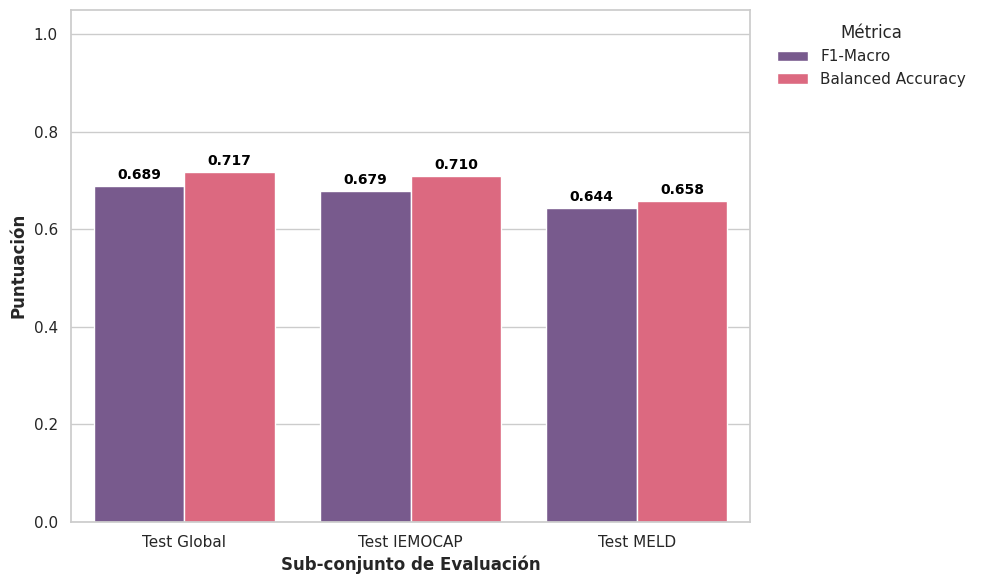

In [19]:
datos_desglose = {
    'Partición de Evaluación': ['Test Global', 'Test MELD', 'Test IEMOCAP'],
    'F1-Macro': [0.6891, 0.6443, 0.6793],
    'Balanced Accuracy': [0.7173, 0.6581, 0.7098], 
    'Recall Estrés': [0.6454, 0.4532, 0.7807], 
    'ROC-AUC': [0.7837, 0.7168, 0.8008]
}

df_desglose = pd.DataFrame(datos_desglose).sort_values(by="F1-Macro", ascending=False).reset_index(drop=True)


df_desglose.to_csv('tabla_sesgo_dominio_global_test.csv', index=False)
display(df_desglose.style.background_gradient(
    subset=['F1-Macro', 'Balanced Accuracy', 'Recall Estrés', 'ROC-AUC'], 
    cmap='Blues'
).format(precision=4))


df_grafica = df_desglose[['Partición de Evaluación', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Partición de Evaluación', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colores = ['#7A5195', '#EF5675'] 

barplot = sns.barplot(
    data=df_melted, 
    x='Partición de Evaluación', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores 
)

plt.ylim(0, 1.05)
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Sub-conjunto de Evaluación', fontsize=12, fontweight='bold')

for p in barplot.patches:
    altura = p.get_height()
    if pd.notnull(altura) and altura > 0:
        barplot.annotate(f"{altura:.3f}", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    fontsize=10, color='black', fontweight='bold',
                    xytext=(0, 8), 
                    textcoords='offset points')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()

nombre_img = 'Fig_sesgo_dominio_global_test.png'
plt.savefig(nombre_img, dpi=300, bbox_inches='tight')
plt.show()

Vemos que presenta un gran equilibrio para ambas particiones, siendo MELD la que peor rendimiento obtiene (debido al ruido que presenta este dataset en comparación con IEMOCAP), que el modelo encuentra más difícil detectar las muestras de estrés en él, pero la diferencia con respecto a IEMOCAP no es extrema. Se confirma que el modelo no presenta sesgo en cuanto a la fuente de datos. 


## **Análisis de sesgo de género del modelo Global**

Gracias a la variable 'gender' presente en el dataset global unificado construido, vamos a detectar si el modelo presenta un comportamiento distinto para las muestras positivas por cada género ('female' o 'male'). Esto nos permite detectar si realmente nuestro modelo entrenado sobre el corpus global unificado es robusto (mayor capacidad de generalización) con respecto al género del hablante. 

100%|██████████| 4257/4257 [00:20<00:00, 211.29it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.51 ms / muestra
ROC-AUC Score: 0.7837
F1 Macro: 0.6891
F1 Weighted: 0.7690
Accuracy (en %): 75.69%
Balanced Accuracy (en %): 71.73%

 ANÁLISIS DE SESGO DE GÉNERO: 
 FEMENINO  (N=1758): F1-Macro: 0.6821 | Recall: 0.6538 | FPR: 0.2305
 MASCULINO (N=2046): F1-Macro: 0.6914 | Recall: 0.6620 | FPR: 0.2253


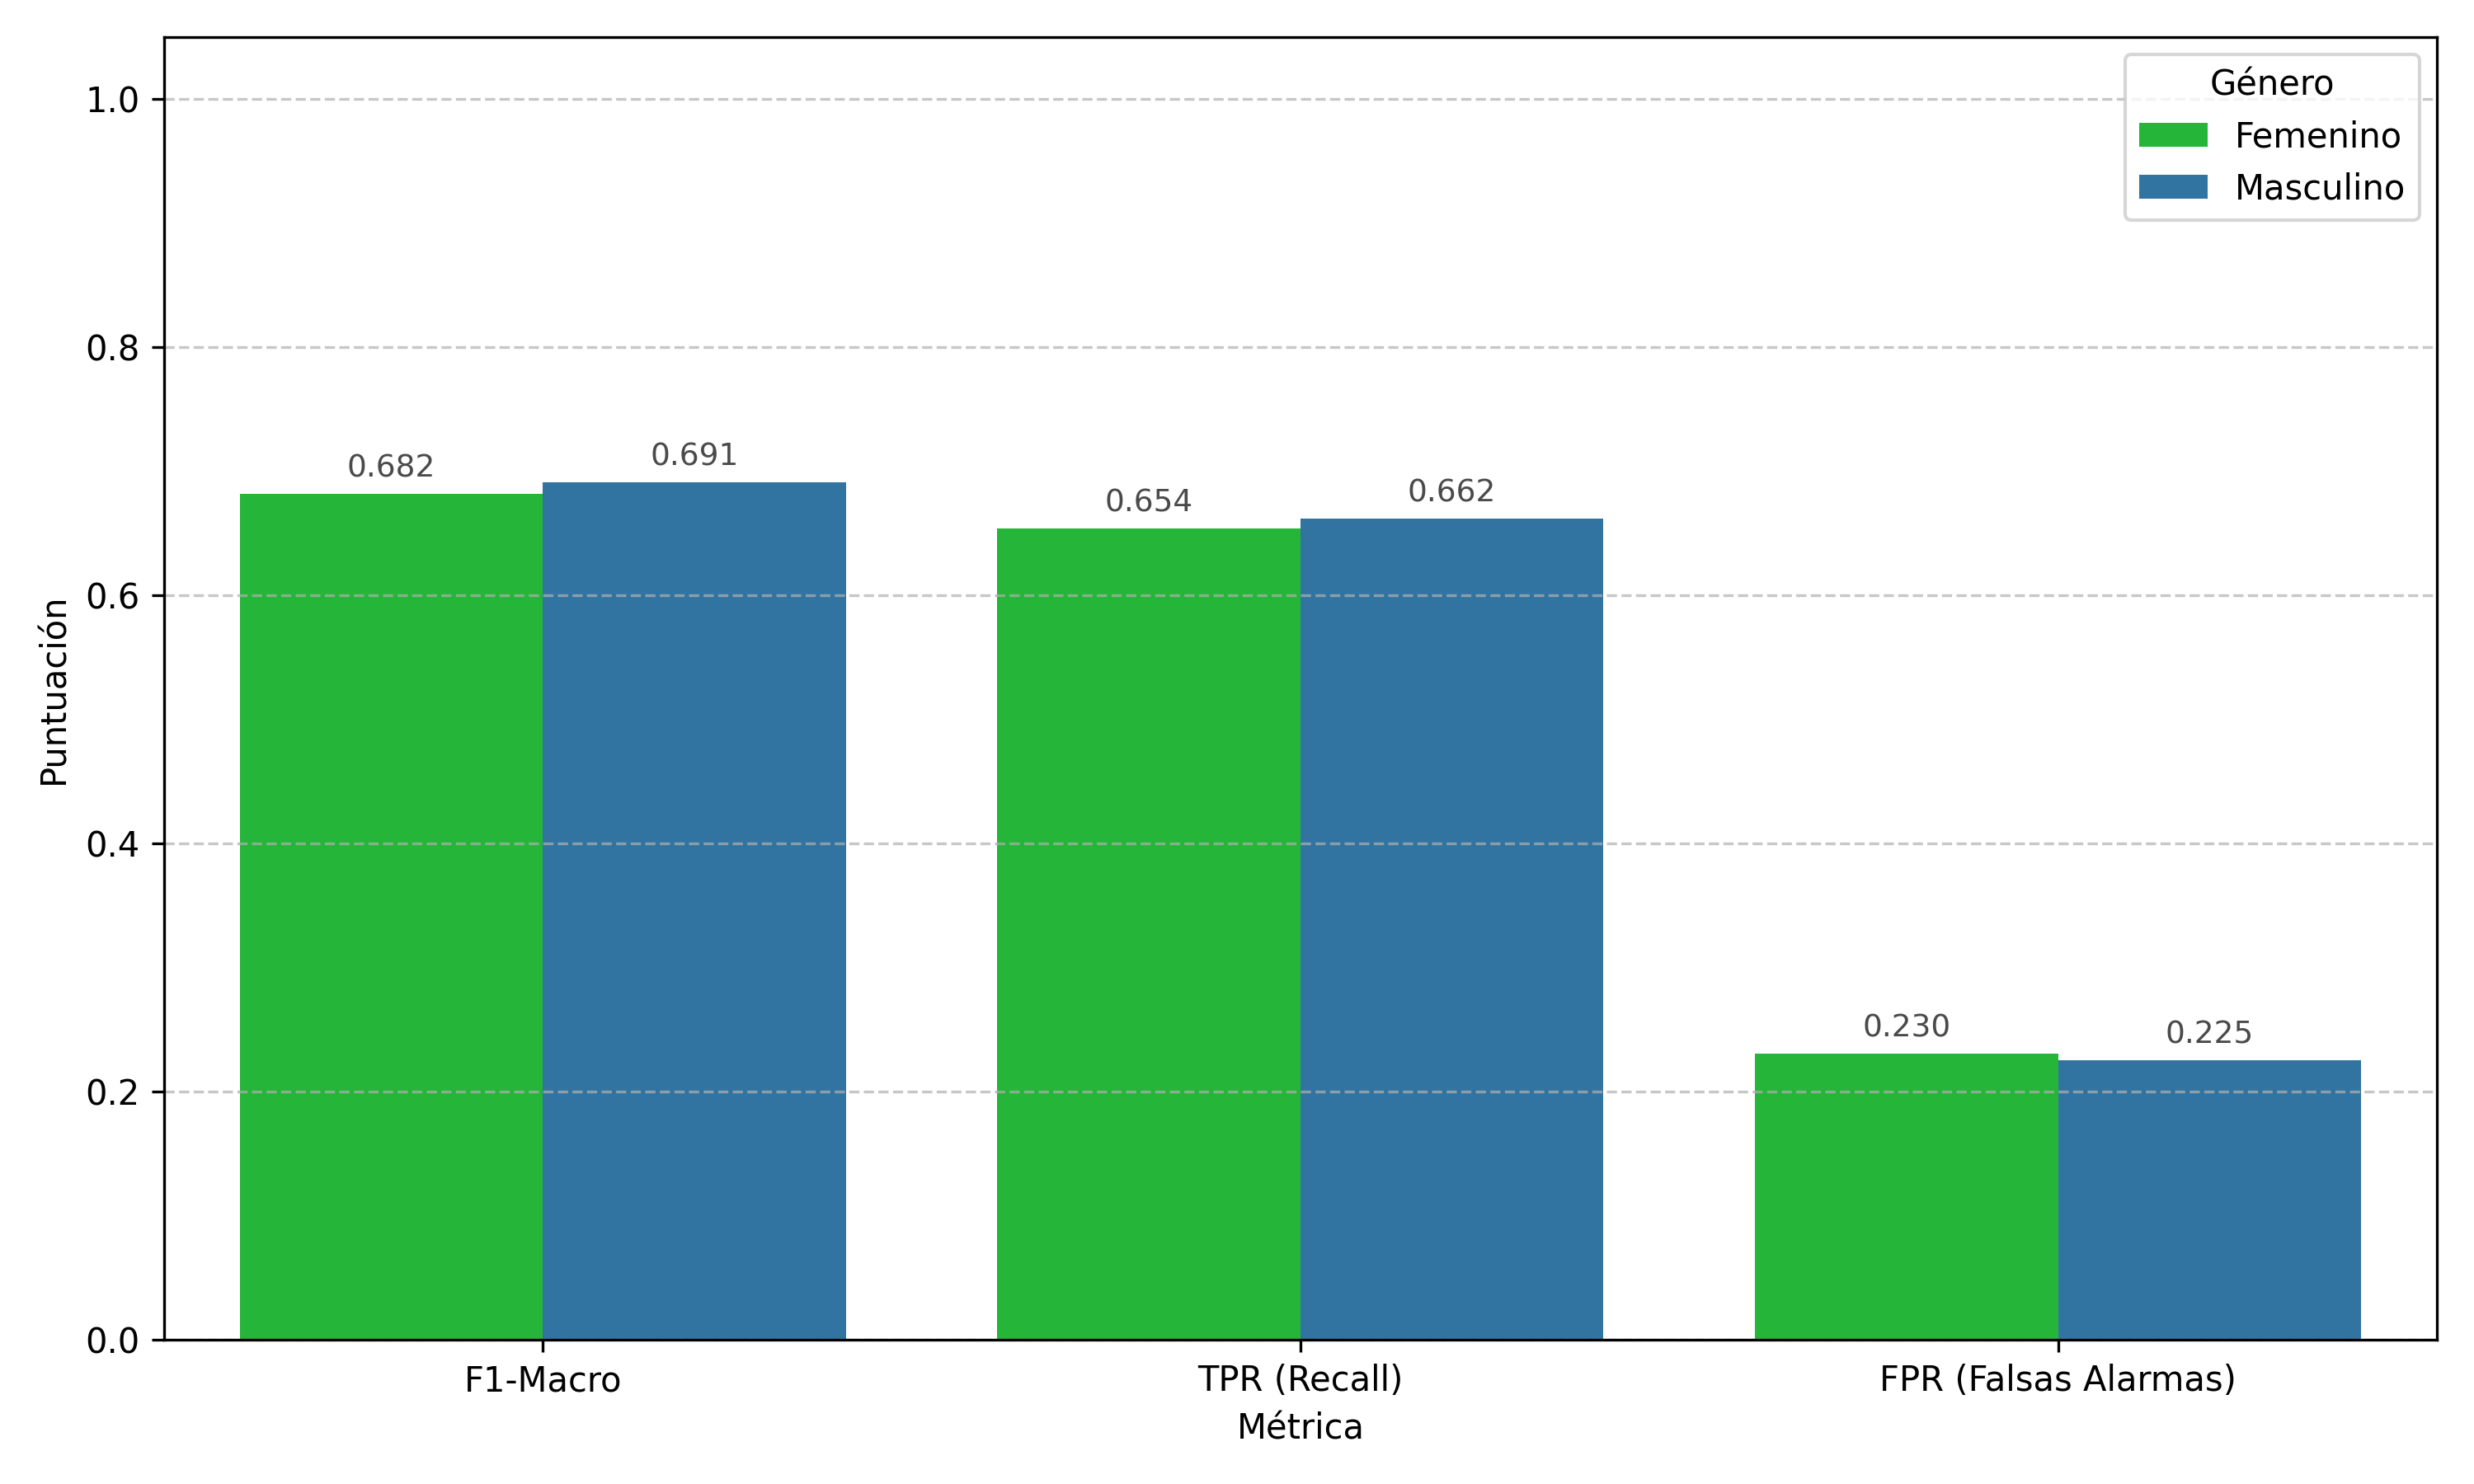

In [18]:
path_pesos = "pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--gender_bias True ")
                        
subprocess.run(comando, shell=True)

nombre_archivo = "Fig_sesgo_genero_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_global_test.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo))

La diferencia en F1-Macro obtenido para ambos géneros es muy pequeña (no llega al 1%), indicando que no hay evidencia de un sesgo de género fuerte, siendo el rendimiento similar en ambos grupos. Ocurre lo mismo para Recall y False Positive Rate, indicando esta última métrica que no hay un grupo que reciba más "falsas alarmas" que otro.

-------
## **t-SNE**

A continuación, se emplea el algoritmo de reducción de dimensionalidad no lineal **t-SNE** para proyectar las características a un espacio bidimensional y así visualizar el espacio latente de los modelos. Los embeddings que extraemos de cada una de las técnicas de fusión son los siguientes:

- **Modelo Global (MELD + IEMOCAP) - Fusión mediante Atención**: Extraemos el vector de características de la última capa oculta (`hidden_mlp` = 128 dimensiones) del clasificador MLP, antes de la neurona de decisión final. Esto permite visualizar el espacio latente puro del clasificador, donde las tres modalidades ya han sido ponderadas e integradas por los mecanismos de atención. 

- **Modelo MELD - Fusión Tardía mediante Regresión Logística**: Al ser un mecanismo de fusión tardía, no existe un espacio latente multimodal previo. Por tanto, el t-SNE se aplica sobre el propio "espacio de decisión", es decir, se extraen las predicciones (logits) independientes de las tres modalidades. Esto ilustra visualmente cómo la capa logística final encuentra la frontera de separación óptima basada en los votos unimodales.

- **Modelo IEMOCAP - Fusión Temprana**: Para garantizar la mayor coherencia posible y una comparativa justa con la de Atención, se extraen los embeddings exactamente del mismo punto que en Atención: la última capa oculta del clasificador MLP (`hidden_mlp` = 128 dimensiones). De este modo, se evalúa cómo la concatenación temprana logra estructurar la información justo antes de la predicción final.

- Para los **modelos unimodales** (que se comparará a continuación), en la misma línea a las técnicas anteriores, extraemos los embeddings de la capa oculta final del clasificador (UnimodalClassifier) con `hidden_mlp` dimensiones.

- En el caso de los **modelos bimodales**, únicamente para el modelo de **audio y texto**, al ser la técnica de fusión **mediante promedio**, no aplicamos **t-SNE** y simplemente extraemos los logits de cada uno de los MLP individuales, y son los que directamente proyectaremos en un espacio 2D. 

Para poder extraer estos vectores de la red para los datos de test, se emplearán los hooks de Pytorch. De acuerdo a la documentación oficial, estos actúan como "espías" de la red, y permiten interceptar el flujo de datos en puntos intermedios del grafo computacional durante la fase de propagación hacia delante (*forward pass*). Gracias a ellos, automáticamente podemos capturar de las capas indicadas una copia exacta de los tensores de entrada (o también se podría realizar con la de salida), sin alterar nada del código o el comportamiento original de la red, capturando los tensores en el estado original. 

Lo que hacemos, por tanto, es definir estos hooks en las capas indicadas, "enganchándolos" a ellas para que actúen como "listeners" de la red. Cuando los datos empiezan a viajar por la red de forma normal, es PyTorch quien, si en una capa hay un hook, devuelve una copia del tensor y luego prosigue.

Volvemos a recordar que todo esto se realiza para los datos de test. 

In [2]:
# ----------------------------------- PRIMERA FASE: FUNCIÓN DE EXTRACCIÓN DE LOS EMBEDDINGS MEDIANTE HOOKS ----------------------------------

def extraer_embeddings_tsne(model, dataloader, device, tipo_modelo='attention'):
    """
    Usa hooks para extraer las características justo antes de la clasificación final.
    tipo_modelo puede ser: 'attention' (Global), 'early' (IEMOCAP), 'logistica' (MELD, bimodales), o 'unimodal'
    """
    embeddings = []
    labels = []

    # Definimos el "hook":
    def hook_fn(module, input, output):
        embeddings.append(input[0].detach().cpu().numpy())
        # Este lo que hace es tomar la entrada de dicha capa objetivo (input[0], que los inputs en PyTorch vienen empaquetados como una tupla por si la capa recibe varias cosas a la vez, y cogemos solo el primer tensor de datos que está a punto de entrar en esta capa)
        # con .detach() lo que hacemos es desvincular ese tensor del grafo matemático, para sólo quedarnos con el tensor, y no con toda la historia matemática de cómo se calculó
        # con .cpu() pasamos los datos a la memoria RAM (movemos de GPU a CPU)
        # con .numpy(), una vez el tensor está en la CPU, convertimos ese tensor a un array de NumPy.

    # Asignamos el hook (lo "enganchamos") a la capa correcta según la arquitectura:
    if tipo_modelo == 'attention':
        # En AttentionFusion, la última capa es model.classifier[4]
        hook = model.classifier[4].register_forward_hook(hook_fn)
    elif tipo_modelo == 'early':
        # En EarlyFusion, la última capa es model.mlp[8]
        hook = model.mlp[8].register_forward_hook(hook_fn)
    elif tipo_modelo == 'logistica':
        # En LateFusion (Logística), la capa final es model.logistic_fusion
        hook = model.logistic_fusion.register_forward_hook(hook_fn)
    elif tipo_modelo == 'unimodal':
        # En UnimodalClassifier, la capa final es model.classifier[4]
        hook = model.classifier[4].register_forward_hook(hook_fn)
    else:
        raise ValueError("tipo_modelo no válido.")

    # A continuación, le pasamos los datos de TEST
    model.eval()
    with torch.no_grad():
        for batch in dataloader: 
            batch_labels = batch['label'].to(device)
            video_x = batch['video'].to(device) if 'video' in batch else None
            audio_x = batch['audio'].to(device) if 'audio' in batch else None
            text_x = batch['texto'].to(device) if 'texto' in batch else None

            if tipo_modelo == 'unimodal':
                unico_input = video_x if video_x is not None else (audio_x if audio_x is not None else text_x)
                _ = model(unico_input)
            else:
                _ = model(video_x=video_x, audio_x=audio_x, text_x=text_x)
            
            labels.extend(batch_labels.cpu().numpy().flatten())

    # Limpiamos el hook para no saturar la memoria
    hook.remove()
    
    return np.concatenate(embeddings, axis=0), np.array(labels)




# ------------------------------------------------ SEGUNDA FASE: t-SNE y VISUALIZACIÓN -----------------------------------------------------


def grafica_tsne(X_embeddings, y_labels, titulo, perplexity=30, guardar_como=None):
    """
    Aplica t-SNE a los embeddings extraídos y genera la gráfica de Seaborn
    """
    print(f"t-SNE para: {titulo}.")
    # Ajustamos perplexity por si el dataset de test es muy pequeño:
    # El creador de t-SNE recomienda que el perplexity siempre sea MENOR al número total de muestras que tenemos
    # En este sentido, lo que hacemos es quedarnos con el mínimo:
    # perplexity = 30 es el estándar recomendado, para separar los clusters de forma suave
    n_muestras = len(y_labels)
    perplex = min(perplexity, n_muestras - 1) 

    # Aplicamos t-SNE:
    
    tsne = TSNE(n_components=2, # Indicamos el número de dimensiones de salida, que lo reducimos a 2D para visualizar (por ejemplo, los vectores de 128 dimensiones extraídos pasan a ser de 2 dimensiones para visualizar en un plano 2D con eje X e Y)
                perplexity=perplex, 
                max_iter=1000, #t-SNE es un algoritmo de optimización que requiere de varias iteraciones 
                random_state=42) # t-SNE tiene un paso inicial que es aleatorio, ponemos la semilla para garantizar la reproducibilidad
    X_tsne = tsne.fit_transform(X_embeddings) # Aplicamos t-SNE a los embeddings extraídos

    # X_tsne devuelve por cada uno de los embeddings (muestras en test) vectores de 2 dimensiones (2 columnas), donde la columna 0 es la coordenada X y la columna 1 es la coordenada Y:
    
    df_tsne = pd.DataFrame({
        'Dim 1': X_tsne[:, 0],
        'Dim 2': X_tsne[:, 1],
        'Clase': ['Estrés' if label == 1 else 'No Estrés' for label in y_labels]
    })

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        x='Dim 1', y='Dim 2',
        hue='Clase',
        palette={'Estrés': '#d62728', 'No Estrés': '#1f77b4'}, # Rojo y Azul clásicos
        data=df_tsne,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5
    )

    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel('Dimensión t-SNE 1')
    plt.ylabel('Dimensión t-SNE 2')
    plt.legend(title='Estado')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    if guardar_como:
        plt.savefig(guardar_como, dpi=300)
    plt.show()

* **Modelo Global - Fusión mediante Atención**:

t-SNE para: Espacio Latente (t-SNE) - Modelo Global (Fusión por Atención).


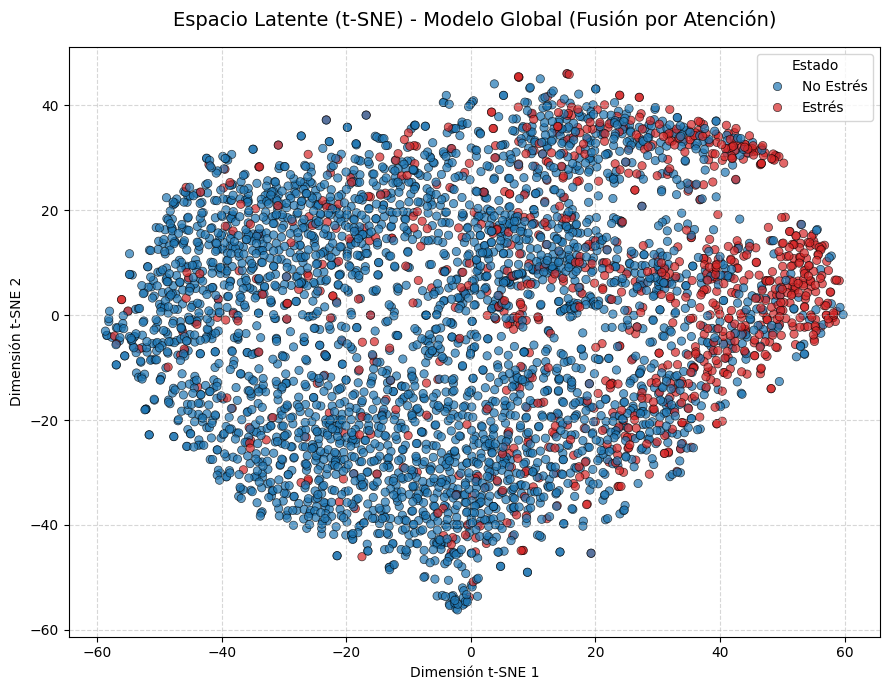

In [3]:
# Extraemos los embeddings del modelo Global (Atención) en TEST
csv_path = os.path.join(BASE_DIR, 'Multimodal_Stress_Dataset.csv')
df = pd.read_csv(csv_path)
df_test = df[df['split'] == 'test'].copy()

df_test['file_id'] = (df_test['dataset_origin'].astype(str) + "_" + df_test['Utterance_ID'].astype(str)).str.replace("/", "_")
test_ids = df_test['file_id'].tolist()
test_labels = df_test['target_stress'].tolist()

modelo = AttentionFusion(visual_dim=2048, audio_dim=768, text_dim=768, proj_dim=512, hidden_mlp=128, dropout_prob=0.3)
modelo.load_state_dict(torch.load("pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth", map_location=device))
modelo = modelo.to(device)

test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test,
        video_model_name = 'resnet',
        audio_model_name = 'wav2vec', 
        text_model_name = 'roberta32',
        base_dir=BASE_DIR,
        video_folder='EMBEDDINGS_VISUAL',
        audio_folder='EMBEDDINGS_AUDIO',
        text_folder='EMBEDDINGS_TEXTO', 
        max_audio_len=350, 
        max_video_frames=32
    )

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


X_emb_global, y_labels_global = extraer_embeddings_tsne(
    model=modelo, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='attention'
)

grafica_tsne(
    X_emb_global, 
    y_labels_global, 
    titulo="Espacio Latente (t-SNE) - Modelo Global (Fusión por Atención)", 
    guardar_como="tsne_global_attention.png"
)

Vemos que en el espacio latente de nuestro modelo entrenado sobre el corpus global unificado, las muestras de ambas clases se encuentran muy mezcladas, aunque se presenta una ligera tendencia a que la zona derecha del gráfico concentre algo más de muestras "rojas" (estrés), pero esta separación es débil, no hay fronteras claras. Esto indica que el modelo no ha aprendido un espacio latente perfectamente discriminativo para estrés vs no estrés, lo cual es coherente con las métricas obtenidas. Claramente, estamos observando que la tarea de detección de estrés no se manifiesta de forma aislada para que sea fácil de identificar, sino que comparte muchas de las características acústicas, visuales y textuales con estados no estresados.

* **Modelo MELD - Fusión Tardía mediante Regresión Logística**:

t-SNE para: Espacio Latente (t-SNE) - Modelo MELD (Fusión Tardía mediante Regresión Logística).


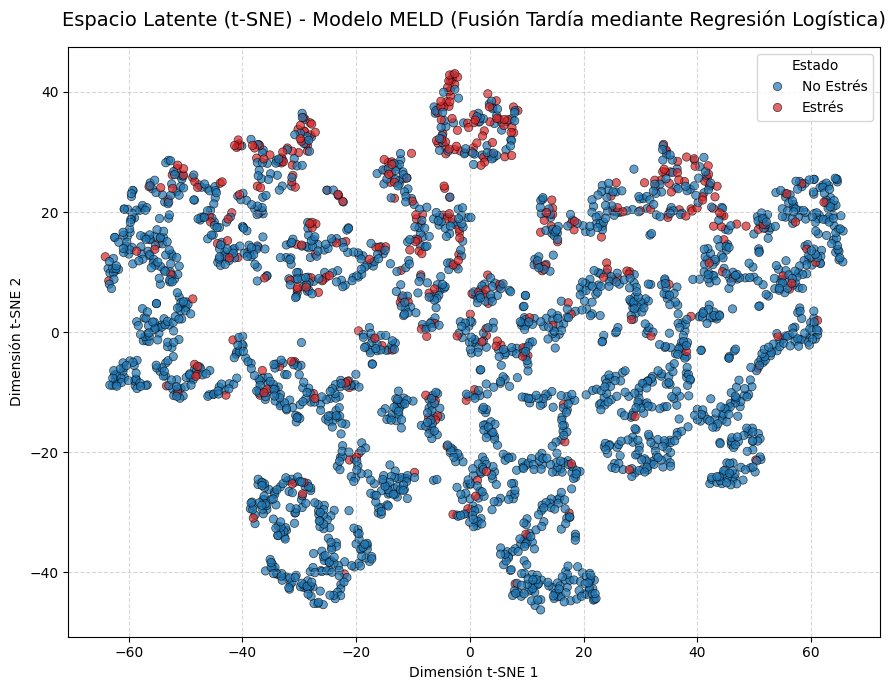

In [4]:
# Extraemos los embeddings del modelo en MELD (Regr. Logística) en TEST

df_test_meld = df_test[df_test['dataset_origin'] == 'MELD'].copy()
test_ids = df_test_meld['file_id'].tolist()
test_labels = df_test_meld['target_stress'].tolist()

modelo = LateFusion(visual_dim=2048, audio_dim=768, text_dim=768, proj_dim=512, hidden_mlp=128, dropout_prob=0.5, fusion_mode='logistica')
modelo.load_state_dict(torch.load("pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth", map_location=device))
modelo = modelo.to(device)

test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test_meld,
        video_model_name = 'resnet',
        audio_model_name = 'wav2vec', 
        text_model_name = 'roberta32',
        base_dir=BASE_DIR,
        video_folder='EMBEDDINGS_VISUAL',
        audio_folder='EMBEDDINGS_AUDIO',
        text_folder='EMBEDDINGS_TEXTO', 
        max_audio_len=350, 
        max_video_frames=32
    )

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) 



X_emb_meld, y_labels_meld = extraer_embeddings_tsne(
    model=modelo, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='logistica'
)

grafica_tsne(
    X_emb_meld, 
    y_labels_meld, 
    titulo="Espacio Latente (t-SNE) - Modelo MELD (Fusión Tardía mediante Regresión Logística)", 
    guardar_como="tsne_meld_logistica.png"
)

Si antes se podía visualizar algo mejor la separación, aquí las muestras están mucho más "mezcladas", además de que se presentan en general muchas menos muestras. 

* **Modelo IEMOCAP - Fusión Temprana**:

t-SNE para: Espacio Latente (t-SNE) - Modelo IEMOCAP (Fusión Temprana).


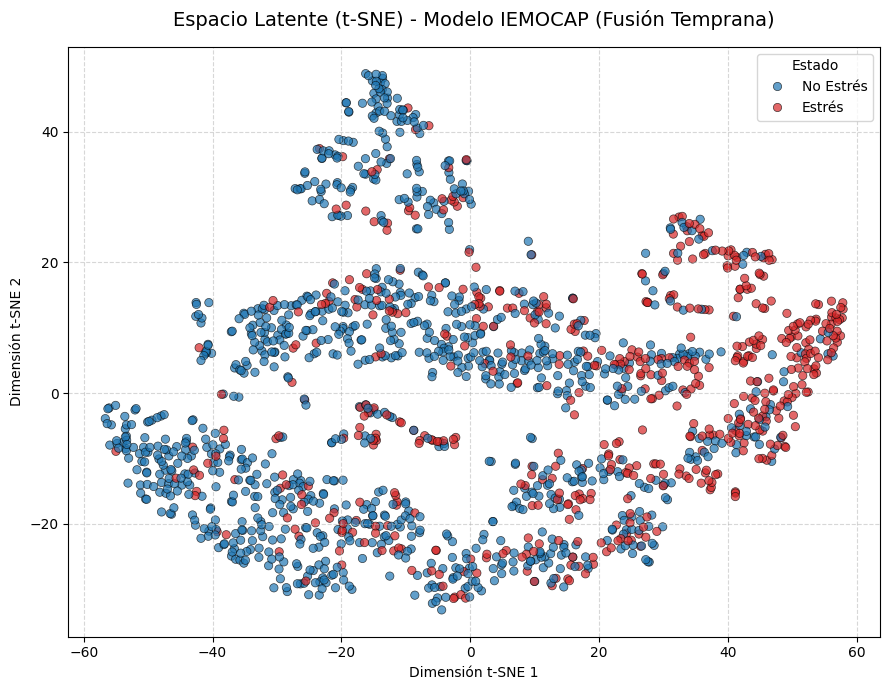

In [5]:
# Extraemos los embeddings del modelo en IEMOCAP (Fusión Temprana) en TEST

df_test_iemocap = df_test[df_test['dataset_origin'] == 'IEMOCAP'].copy()
test_ids = df_test_iemocap['file_id'].tolist()
test_labels = df_test_iemocap['target_stress'].tolist()

modelo = EarlyFusion(visual_dim=2048, audio_dim=768, text_dim=768, proj_dim=512, hidden_mlp=128, dropout_prob=0.3)
modelo.load_state_dict(torch.load("pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth", map_location=device))
modelo = modelo.to(device)

test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test_iemocap,
        video_model_name = 'resnet',
        audio_model_name = 'wav2vec', 
        text_model_name = 'roberta32',
        base_dir=BASE_DIR,
        video_folder='EMBEDDINGS_VISUAL',
        audio_folder='EMBEDDINGS_AUDIO',
        text_folder='EMBEDDINGS_TEXTO', 
        max_audio_len=350, 
        max_video_frames=32
    )

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) # Batch 1 para medir tiempo de inferencia real


X_emb_iemocap, y_labels_iemocap = extraer_embeddings_tsne(
    model=modelo, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='early'
)

grafica_tsne(
    X_emb_iemocap, 
    y_labels_iemocap, 
    titulo="Espacio Latente (t-SNE) - Modelo IEMOCAP (Fusión Temprana)", 
    guardar_como="tsne_iemocap_temprana.png"
)

Al igual que el modelo global, este presenta una tendencia en separar las muestras de estrés (derecha) y no estrés (izquierda), pero también presenta dispersión de las muestras por toda la nube de puntos, confirmando que para todos los modelos multimodales (intra e inter-dominio), no consiguen separar perfectamente en dos clústers las muestras de estrés y no estrés. 

* **UNIMODAL: RoBERTa**:

t-SNE para: Espacio Latente (t-SNE) - Modelo Unimodal RoBERTa.


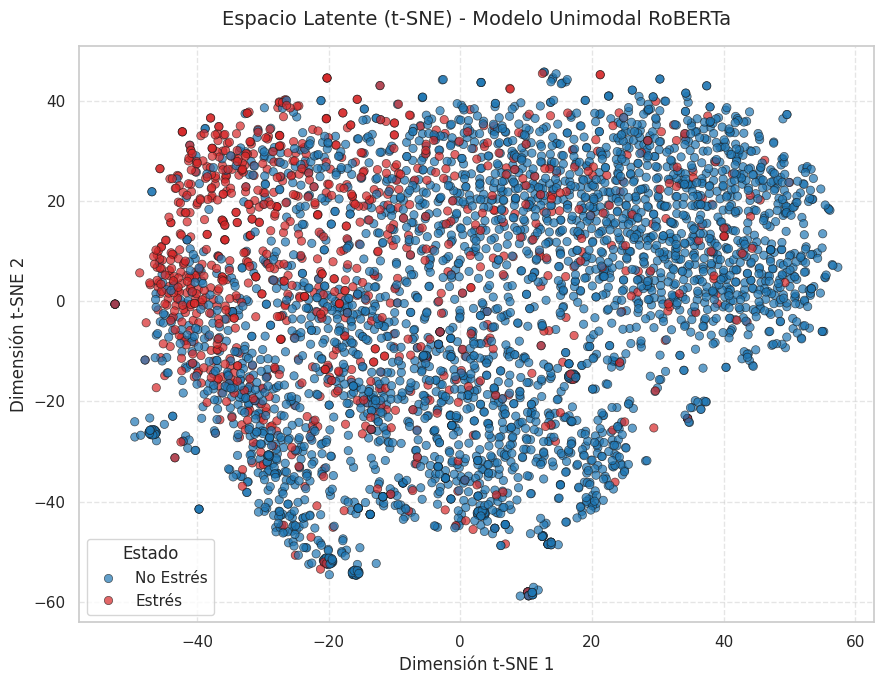

In [29]:
test_dataset = MultimodalStressDataset(subject_ids=test_ids, labels=test_labels, df=df_test, text_model_name='roberta64', base_dir=BASE_DIR, text_folder='EMBEDDINGS_TEXTO', modalidades=['texto'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(TextAdapter(input_dim=768, dropout_prob=0.3), dropout_prob=0.3).to(device)
model_eval.load_state_dict(torch.load("pesos/unimodales_ajuste/pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.3_lr5e-05.pth"))

X_emb_roberta, y_labels_roberta = extraer_embeddings_tsne(
    model=model_eval, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='unimodal'
)


grafica_tsne(
    X_emb_roberta, 
    y_labels_roberta, 
    titulo="Espacio Latente (t-SNE) - Modelo Unimodal RoBERTa", 
    guardar_como="tsne_roberta_unimodal.png"
)

Se observa en RoBERTa una tendencia a separar las muestras, como se observaba en el modelo global, mostrando, en este caso, más muestras positivas a la izquierda de la gráfica, y a la derecha más muestras negativas. 

* **UNIMODAL: Wav2Vec 2.0**:

t-SNE para: Espacio Latente (t-SNE) - Modelo Unimodal Wav2Vec 2.0.


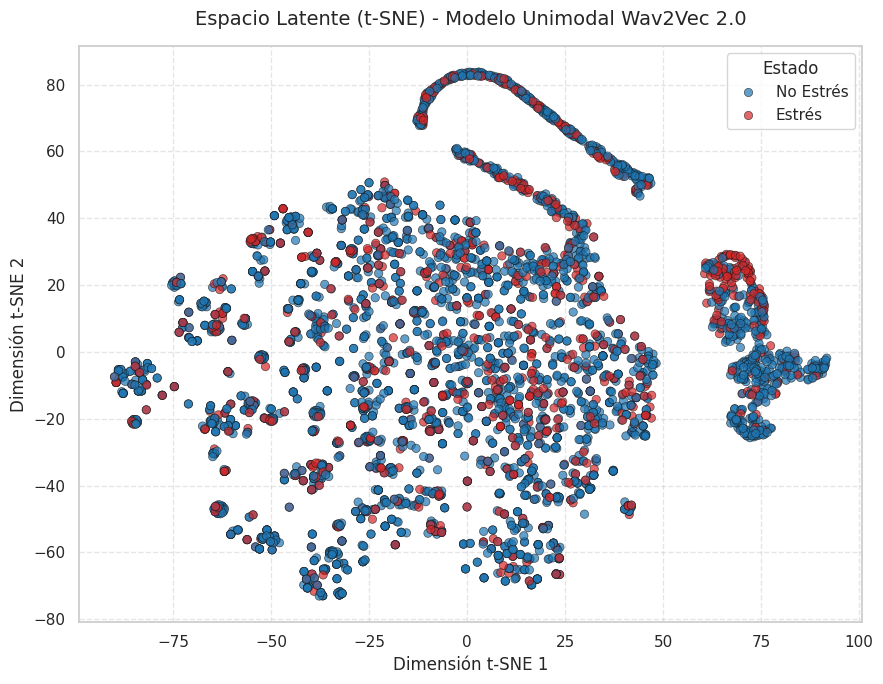

In [35]:
test_dataset = MultimodalStressDataset(subject_ids = test_ids, labels= test_labels, df= df_test, audio_model_name='wav2vec', base_dir=BASE_DIR, audio_folder='EMBEDDINGS_AUDIO', max_audio_len=350, modalidades=['audio'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_dim_wav2vec = 768

model_eval = UnimodalClassifier(AudioAdapter(input_dim=input_dim_wav2vec, dropout_prob=0.3), dropout_prob=0.3).to(device)
model_eval.load_state_dict(torch.load("pesos/unimodales_ajuste/pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.3_lr0.0001.pth"))


X_emb_wav2vec, y_labels_wav2vec = extraer_embeddings_tsne(
    model=model_eval, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='unimodal'
)

grafica_tsne(
    X_emb_wav2vec, 
    y_labels_wav2vec, 
    titulo="Espacio Latente (t-SNE) - Modelo Unimodal Wav2Vec 2.0", 
    guardar_como="tsne_wav2vec_unimodal.png"
)

Aquí se observa que las muestras se encuentran mucho más dispersas por toda la gráfica, además de mostrar la formación de diversos clústers pequeños que no llegan a diferenciarse claramente ni logran distinguir entre muestres de estrés y no estrés. 

* **UNIMODAL: ResNet**:

t-SNE para: Espacio Latente (t-SNE) - Modelo Unimodal ResNet.


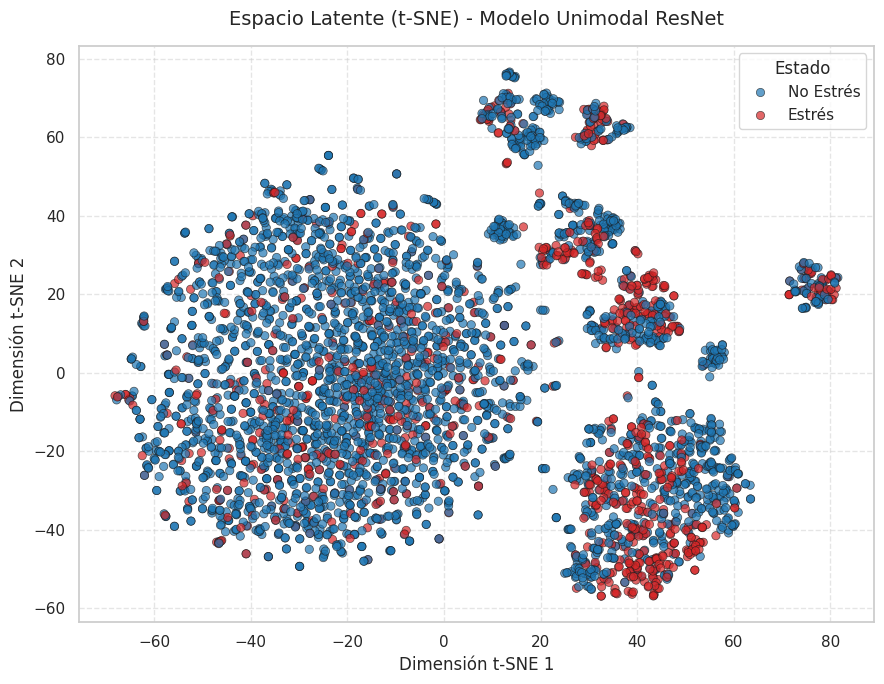

In [37]:
test_dataset = MultimodalStressDataset(subject_ids=test_ids, labels=test_labels, df=df_test, video_model_name='resnet', base_dir=BASE_DIR, video_folder='EMBEDDINGS_VISUAL',max_video_frames=32, modalidades=['video'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



input_dim_resnet = 2048
hidden_lstm_calc = max(256, input_dim_resnet // 4) # Al ser proj_dim = 256, debemos aplicar la misma fórmula para calcular el hidden_lstm que en el entrenamiento

model_eval = UnimodalClassifier(VisualAdapter(input_dim=input_dim_resnet, projection_dim=256, hidden_lstm=hidden_lstm_calc, dropout_prob=0.3), proj_dim = 256, hidden_mlp=64, dropout_prob=0.3).to(device)
model_eval.load_state_dict(torch.load("pesos/unimodales_ajuste/pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth"))

X_emb_resnet, y_labels_resnet = extraer_embeddings_tsne(
    model=model_eval, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='unimodal'
)

grafica_tsne(
    X_emb_resnet, 
    y_labels_resnet, 
    titulo="Espacio Latente (t-SNE) - Modelo Unimodal ResNet", 
    guardar_como="tsne_resnet_unimodal.png"
)

Muestra una tendencia similar a la observada en Wav2Vec 2.0, y es la formación de pequeños clústers, pero tampoco logra ditinguir correctamente en muestras de estrés y no estrés.

* **BIMODAL: Vídeo + Audio**:

t-SNE para: Espacio Latente (t-SNE) - Baseline Bimodal Vídeo + Audio (Fusión Tardía mediante Regresión Logística).


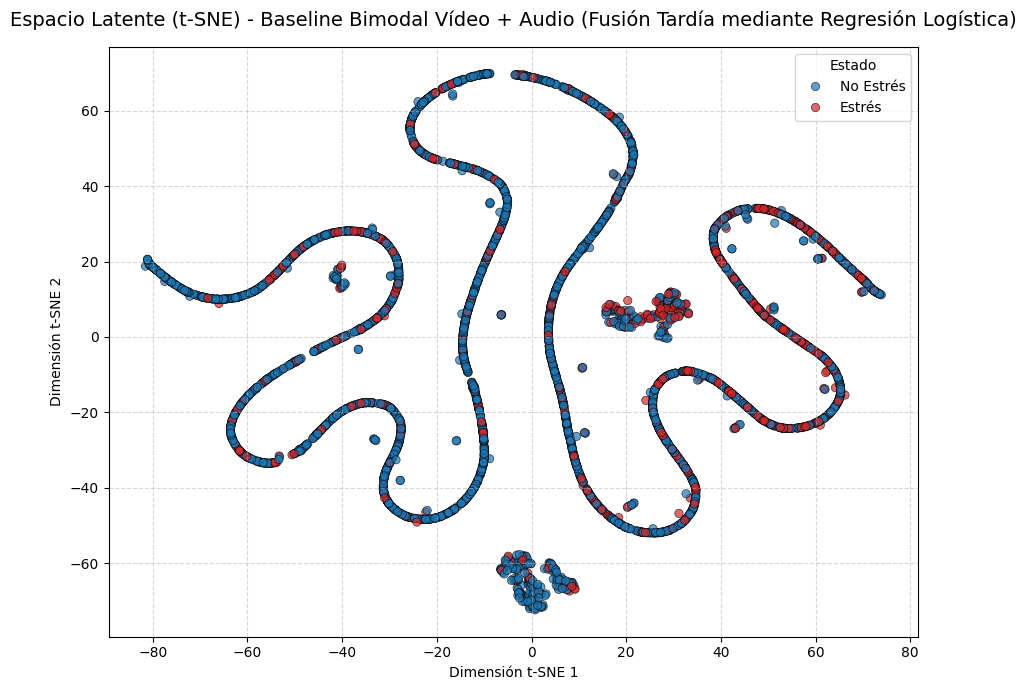

In [10]:
csv_path = os.path.join(BASE_DIR, 'Multimodal_Stress_Dataset.csv')
df = pd.read_csv(csv_path)
df_test = df[df['split'] == 'test'].copy()

df_test['file_id'] = (df_test['dataset_origin'].astype(str) + "_" + df_test['Utterance_ID'].astype(str)).str.replace("/", "_")
test_ids = df_test['file_id'].tolist()
test_labels = df_test['target_stress'].tolist()

test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test,
        video_model_name = 'resnet',
        audio_model_name = 'wav2vec',
        base_dir=BASE_DIR,
        video_folder='EMBEDDINGS_VISUAL',
        audio_folder='EMBEDDINGS_AUDIO',
        max_audio_len=350, 
        max_video_frames=16,
        modalidades=['video','audio']
    )

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

modelo = LateFusion(visual_dim=2048, audio_dim=768, proj_dim=256, hidden_mlp=64, dropout_prob=0.3, fusion_mode='logistica', modalidades=['video', 'audio'])
modelo.load_state_dict(torch.load("pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth", map_location=device))
modelo = modelo.to(device)

X_emb_va, y_labels_va = extraer_embeddings_tsne(
    model=modelo, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='logistica'
)

grafica_tsne(
    X_emb_va, 
    y_labels_va, 
    titulo="Espacio Latente (t-SNE) - Baseline Bimodal Vídeo + Audio (Fusión Tardía mediante Regresión Logística)", 
    guardar_como="tsne_meld_bimodal_video_audio.png"
)

En este primer modelo bimodal, se observa la misma tendencia que Wav2Vec 2.0, donde se forman estructuras curvilíneas separadas, sin presentar una frontera clara entre estrés y no estrés.

* **BIMODAL: Vídeo + Texto**:

t-SNE para: Espacio Latente (t-SNE) - Baseline Bimodal Vídeo + Texto (Fusión Tardía mediante Regresión Logística).


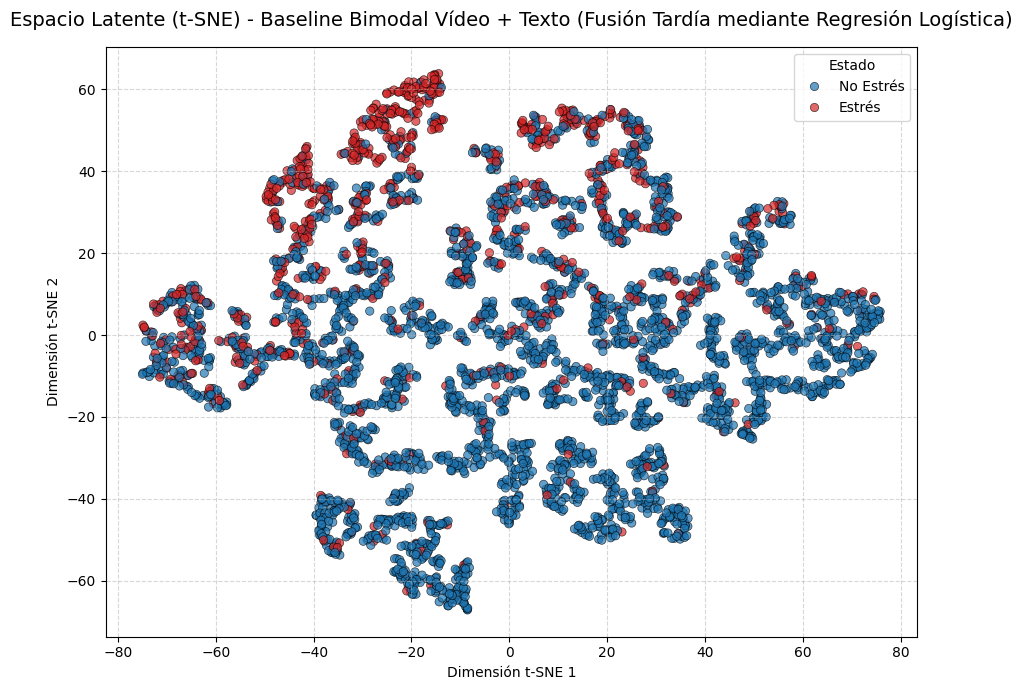

In [11]:
test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test,
        video_model_name = 'resnet',
        text_model_name='roberta64',
        base_dir=BASE_DIR,
        video_folder='EMBEDDINGS_VISUAL',
        text_folder='EMBEDDINGS_TEXTO',
        max_video_frames=32,
        modalidades=['video','texto']
    )

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

modelo = LateFusion(visual_dim=2048, text_dim=768, proj_dim=512, hidden_mlp=128, dropout_prob=0.5, fusion_mode='logistica', modalidades=['video', 'texto'])
modelo.load_state_dict(torch.load("pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth", map_location=device))
modelo = modelo.to(device)

X_emb_vt, y_labels_vt = extraer_embeddings_tsne(
    model=modelo, 
    dataloader=test_loader, 
    device=device, 
    tipo_modelo='logistica'
)

grafica_tsne(
    X_emb_vt, 
    y_labels_vt, 
    titulo="Espacio Latente (t-SNE) - Baseline Bimodal Vídeo + Texto (Fusión Tardía mediante Regresión Logística)", 
    guardar_como="tsne_meld_bimodal_video_texto.png"
)

Se consigue visualizar mejor la separación, tendiendo las muestras de estrés (rojas) al lado izquierdo de la gráfica, pero tampoco consigue una separación clara. 

* **BIMODAL: Audio + Texto**

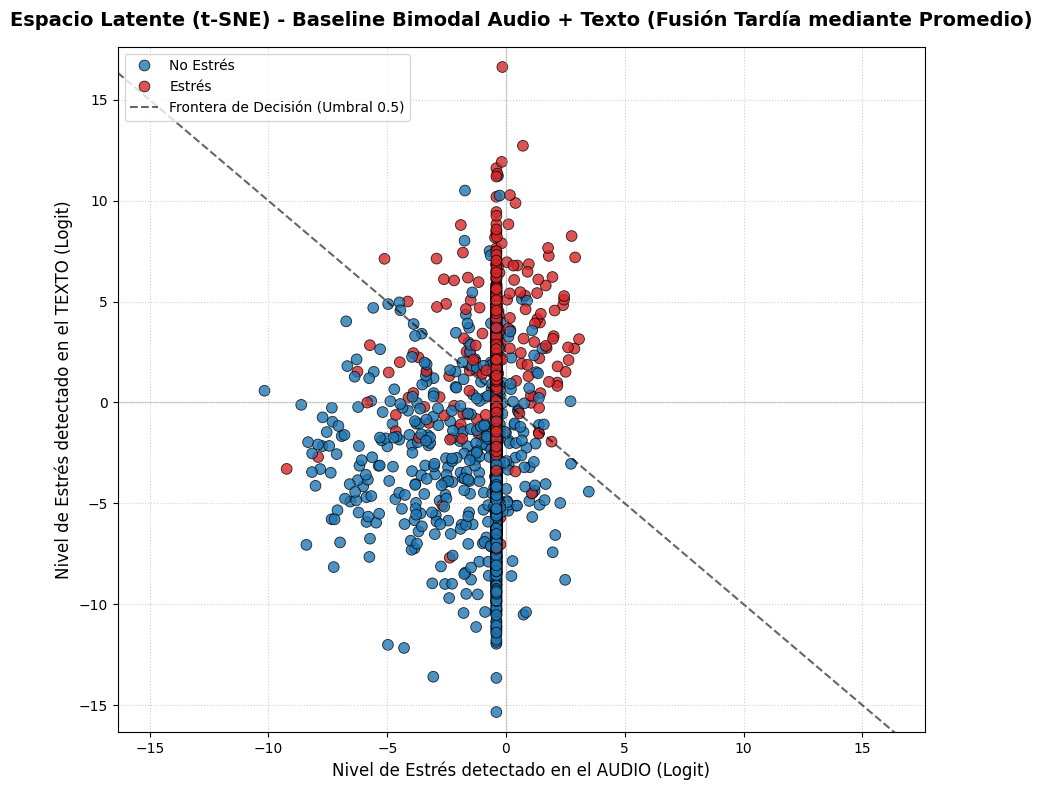

In [12]:
test_dataset = MultimodalStressDataset(
        subject_ids=test_ids, 
        labels=test_labels,
        df = df_test,
        audio_model_name = 'wav2vec',
        text_model_name='roberta64',
        base_dir=BASE_DIR,
        audio_folder='EMBEDDINGS_AUDIO',
        text_folder='EMBEDDINGS_TEXTO',
        max_audio_len=350,
        modalidades=['audio','texto']
    )

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

modelo = LateFusion(audio_dim=768, text_dim=768, proj_dim=512, hidden_mlp=128, dropout_prob=0.3, fusion_mode='promedio', modalidades=['audio', 'texto'])
modelo.load_state_dict(torch.load("pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth", map_location=device))
modelo = modelo.to(device)


modelo.eval()
logits = []
labels_list = []

################### FORWARD ####################
with torch.no_grad():
        for batch in test_loader:
            labels = batch['label'].to(device)
            audio_x = batch['audio'].to(device) if 'audio' in batch else None
            text_x = batch['texto'].to(device) if 'texto' in batch else None

            # Le pedimos el "espacio latente" (que en este modelo son los 2 logits unidos)
            _, stacked_logits = modelo(audio_x=audio_x, text_x=text_x, return_latent=True)

            logits.append(stacked_logits.cpu().numpy())
            labels_list.extend(labels.cpu().numpy().flatten())

logits = np.concatenate(logits, axis=0)
labels = np.array(labels_list)
    

df = pd.DataFrame({
        'Logit Audio': logits[:, 0],
        'Logit Texto': logits[:, 1],
        'Clase': ['Estrés' if l == 1 else 'No Estrés' for l in labels]
    })

plt.figure(figsize=(9, 8))
sns.scatterplot(
        data=df,
        x='Logit Audio',
        y='Logit Texto',
        hue='Clase',
        palette={'Estrés': '#d62728', 'No Estrés': '#1f77b4'},
        alpha=0.8,
        edgecolor='k',
        s=60) # Tamaño de los puntos

 # --- DIBUJAMOS LA FRONTERA DE DECISIÓN ---
# Todo lo que esté por encima/derecha de esta línea el modelo lo clasifica como Estrés
limite_min = min(logits[:, 0].min(), logits[:, 1].min()) - 1
limite_max = max(logits[:, 0].max(), logits[:, 1].max()) + 1
    
plt.plot([limite_min, limite_max], [-limite_min, -limite_max], 
             color='black', linestyle='--', alpha=0.6, 
             label='Frontera de Decisión (Umbral 0.5)')


plt.title("Espacio Latente (t-SNE) - Baseline Bimodal Audio + Texto (Fusión Tardía mediante Promedio)", fontsize=14, pad=15, fontweight='bold')
plt.xlim(limite_min, limite_max)
plt.ylim(limite_min, limite_max)
    
# Líneas de los ejes en el origen (0,0)
plt.axhline(0, color='gray', linewidth=1, alpha=0.3)
plt.axvline(0, color='gray', linewidth=1, alpha=0.3)
    
plt.xlabel('Nivel de Estrés detectado en el AUDIO (Logit)', fontsize=12)
plt.ylabel('Nivel de Estrés detectado en el TEXTO (Logit)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
    
plt.tight_layout()
plt.savefig("tsne_meld_bimodal_audio_texto.png", dpi=300)
plt.show()

Este es uno de los modelos que mejor consigue separar las muestras de estrés y no estrés, aunque no de forma perfecta. 